## Step 1: Importing libraries

### We need our core libraries: 
### 1- os to map the folder paths.
### 2- matplotlib to visually inspect the X-rays later.
### 3- and tensorflow/ImageDataGenerator to handle the actual neural network math and data pipelines.

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

2026-05-08 19:23:26.802827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778268207.026881      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778268207.097305      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778268207.630124      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778268207.630163      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778268207.630166      57 computation_placer.cc:177] computation placer alr

## Step 2: Directory Setup

### Train: Where the model learns the patterns.

### Validation (Val): Where the model takes practice tests during training to ensure it isn't memorizing the data.

### Test: The final, unseen exam.

In [2]:
!pip install -q split-folders
import splitfolders

print("Slicing dataset into Train (80%), Val (10%), and Test (10%)...")

splitfolders.ratio('/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images', 
                   output="/kaggle/working/malaria_split", 
                   seed=42, 
                   ratio=(.8, .1, .1)) 
print("Slicing complete!")

Slicing dataset into Train (80%), Val (10%), and Test (10%)...


Copying files: 27560 files [05:08, 89.36 files/s] 

Slicing complete!


In [3]:
new_base_dir = '/kaggle/working/malaria_split'
target_classes = ['Parasitized', 'Uninfected']

# 1. Standardizing the pixels
datagen = ImageDataGenerator(rescale=1./255)

# 2. Train Generator (80%)
train_generator = datagen.flow_from_directory(
    os.path.join(new_base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    classes=target_classes
)

# 3. Validation Generator (10%)
validation_generator = datagen.flow_from_directory(
    os.path.join(new_base_dir, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    classes=target_classes
)

# 4. Test Generator (10% - for final evaluation)
test_generator = datagen.flow_from_directory(
    os.path.join(new_base_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    classes=target_classes,
    shuffle=False 
)

Found 22046 images belonging to 2 classes.
Found 2756 images belonging to 2 classes.
Found 2756 images belonging to 2 classes.


## Step 3: Counting Classes

### In medical AI, data is almost never balanced. Usually, you have far more "sick" cases than "healthy" ones because hospitals collect data from people who actually show up with symptoms.

### If we don't know the ratio of Uninfected to parasitized images, we might accidentally train a model that just guesses "Pneumonia" every single time to get an 80% score without actually learning anything. We need to know exactly how much the deck is stacked against us.

In [4]:
splits = ['train', 'val', 'test']

total_all = 0

print("--- 3-Way Split Verification ---")

for split in splits:
    print(f"\n[{split.upper()} SET]")
    split_total = 0
    
    for cls in target_classes:
        folder_path = os.path.join(new_base_dir, split, cls)
        # Count the files in this specific subfolder
        num_files = len(os.listdir(folder_path))
        print(f"  {cls}: {num_files} images")
        split_total += num_files
        total_all += num_files
        
    print(f"  Total in {split}: {split_total}")

print("--------------------------------")
print(f"Total dataset images: {total_all}")

--- 3-Way Split Verification ---

[TRAIN SET]
  Parasitized: 11024 images
  Uninfected: 11024 images
  Total in train: 22048

[VAL SET]
  Parasitized: 1378 images
  Uninfected: 1378 images
  Total in val: 2756

[TEST SET]
  Parasitized: 1378 images
  Uninfected: 1378 images
  Total in test: 2756
--------------------------------
Total dataset images: 27560


## Step 4: Hyperparameter Configuration

### Technical Constraints:
### Target Resolution ($224 \times 224$): Mandatory for MobileNetV2 compatibility. This ensures spatial hierarchies align with the model's pre-trained weights.
### Batch Size ($32$): Optimized for Kaggle T4 GPUs (as we're using cloud computing for this project). It provides enough gradient stability to converge without triggering an Out of Memory (OOM) crash.

In [5]:
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

print(f"Configuration Locked: {IMG_WIDTH}x{IMG_HEIGHT} @ Batch Size {BATCH_SIZE}")

Configuration Locked: 224x224 @ Batch Size 32


## Step 5: Stochastic Input Rescaling and Pixel Normalization

### Neural networks struggle with high-variance inputs. Raw pixel values ($0-255$) must be compressed to a $[0, 1]$ range using Min-Max Scaling to ensure gradient stability and prevent weight explosion during backpropagation.

In [6]:
simple_datagen = ImageDataGenerator(rescale=1./255)

## Step 6: Synthetic Data Augmentation for Variance Injection

### To prevent overfitting, where the model memorizes specific training images rather than learning general diagnostic features. we use real-time augmentation. This artificially expands the dataset by applying random, physics-defying transformations to the images every time the model sees them.

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,      
    fill_mode='nearest'
)

## Step 7: Data Stream Mapping and Pipeline Activation

### We have defined the global constraints (Step 4), the standard filter (Step 5), and the mutation filter (Step 6). But right now, they are just empty rules. They aren't connected to your data.

### In this step, we build the "pipes." We are going to connect our ImageDataGenerator objects directly to the Kaggle folders so they can stream the images from the hard drive into the GPU.

In [14]:
# 1. RESET THE FOLDER PATHS (Fixes the TypeError)
new_base_dir = '/kaggle/working/malaria_split'
train_dir = os.path.join(new_base_dir, 'train')
val_dir = os.path.join(new_base_dir, 'val')

# Safety safeguard
target_classes = ['Parasitized', 'Uninfected'] 

# 2. CREATE GENERATORS
print("Connecting Training Pipeline:")
train_generator = train_datagen.flow_from_directory(
    train_dir,                                
    target_size=(IMG_WIDTH, IMG_HEIGHT), 
    batch_size=BATCH_SIZE,               
    class_mode='binary',                 
    classes=target_classes                     
)

print("\nConnecting Validation Pipeline:")
validation_generator = simple_datagen.flow_from_directory(
    val_dir,                                  
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=target_classes                     
)

Connecting Training Pipeline:
Found 22046 images belonging to 2 classes.

Connecting Validation Pipeline:
Found 2756 images belonging to 2 classes.


In [15]:
print("Connecting Training Pipeline:")
train_generator = train_datagen.flow_from_directory(
    train_dir,                               
    target_size=(IMG_WIDTH, IMG_HEIGHT), 
    batch_size=BATCH_SIZE,               
    class_mode='binary',                 
    classes=target_classes                   
)

print("\nConnecting Validation Pipeline:")
validation_generator = simple_datagen.flow_from_directory(
    val_dir,                                  
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=target_classes                   
)

Connecting Training Pipeline:
Found 22046 images belonging to 2 classes.

Connecting Validation Pipeline:
Found 2756 images belonging to 2 classes.


## Step 8: Instantiating the Pre-trained MobileNetV2 Architecture

### If you try to train a Deep Learning model from scratch on just 4,000 images, it will fail miserably. It will memorize the training set, overfit instantly, and be completely useless in the real world.

### To hit our small dataset with high accuracy, we use Transfer Learning. We are going to import Google's MobileNetV2. This model has already spent thousands of GPU hours looking at 1.4 million images (ImageNet) to learn how to detect edges, textures, and complex shapes. We are going to steal that "brain" and just teach it the final step: how to look at an X-ray.

In [16]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',  
    include_top=False,   
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3) 
)

base_model.trainable = False

print("Status: MobileNetV2 base loaded and frozen.")
print(f"Number of pre-trained layers locked: {len(base_model.layers)}")

I0000 00:00:1778268667.697119      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778268667.703399      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Status: MobileNetV2 base loaded and frozen.
Number of pre-trained layers locked: 154


## Step 9: Attaching the Custom Diagnostic Head

### Right now, our model is simply a "feature extractor." It can identify complex textures and shapes, but it has no idea what "Pneumonia" is. We must build a mathematical decision layer on top of the frozen base to translate those visual features into a medical diagnosis.

In [17]:
from tensorflow.keras import layers, models

# Stack the layers linearly
model = models.Sequential([
    base_model,                          
    layers.GlobalAveragePooling2D(),      
    layers.Dropout(0.2),                  
    layers.Dense(1, activation='sigmoid') 
])

print("Status: Architecture completely assembled.")
model.summary()

Status: Architecture completely assembled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Step 10: Model Compilation

### We must assign the model a penalty system (Loss Function) and an update algorithm (Optimizer) before it can train.

### Loss (binary_crossentropy): The standard mathematical penalty for binary (2-class) probability scoring.

### Optimizer (adam): Dynamically adjusts the learning rate to converge efficiently without overshooting.

In [18]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',          
    metrics=['accuracy']
)

## Step 11: Training Safeguards (EarlyStopping)

### To prevent overfitting (where the model memorizes the training data instead of learning patterns), we implement an automated kill-switch. This monitors the model's performance on the validation set and stops training once it stops improving.

### Monitor (val_loss): Focuses on the model's ability to generalize to unseen images.

### Patience (5): Allows for 5 "second chances" if performance plateaus before terminating.

### Restore Best Weights: Automatically reverts the model to its peak performance state, even if it started over-fitting in later rounds.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("Status: EarlyStopping callback active.")

Status: EarlyStopping callback active.


## Step 12: Execution (The Training Loop)

### This is the moment of truth. We are pulling the trigger on the actual training process. The GPU will now take the images, pass them through the frozen MobileNetV2 base, let the diagnostic head make a guess, calculate the error (Loss), and update the weights.

In [22]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[early_stop]      
)

print("\n--- Training Cycle Complete ---")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778268800.816196     247 service.cc:152] XLA service 0x78a8d8110590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778268800.816249     247 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778268800.816254     247 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778268801.888744     247 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-08 19:33:31.006456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 19:33:31.144605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778268813.058181     247 device_co

443/689 ━━━━━━━━━━━━━━━━━━━━ 1:19 323ms/step - accuracy: 0.8206 - loss: 0.3918

2026-05-08 19:36:05.212262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 19:36:05.350054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8432 - loss: 0.3544

2026-05-08 19:37:41.832256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 19:37:41.968028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


689/689 ━━━━━━━━━━━━━━━━━━━━ 268s 364ms/step - accuracy: 0.8433 - loss: 0.3543 - val_accuracy: 0.9013 - val_loss: 0.2324
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 228s 331ms/step - accuracy: 0.9179 - loss: 0.2237 - val_accuracy: 0.9078 - val_loss: 0.2174
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 226s 328ms/step - accuracy: 0.9216 - loss: 0.2118 - val_accuracy: 0.9147 - val_loss: 0.2038
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 229s 333ms/step - accuracy: 0.9245 - loss: 0.2040 - val_accuracy: 0.9202 - val_loss: 0.1957
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 227s 329ms/step - accuracy: 0.9309 - loss: 0.1922 - val_accuracy: 0.9300 - val_loss: 0.1879
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 225s 327ms/step - accuracy: 0.9288 - loss: 0.1959 - val_accuracy: 0.9187 - val_loss: 0.1987
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 225s 326ms/step - accuracy: 0.9311 - loss: 0.1937 - val_accuracy: 0.9213 - val_loss: 0.1933
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 225s 326ms/step - accuracy: 0.9351 - loss: 0.18

## Step 13: Visualizing the Learning Curves

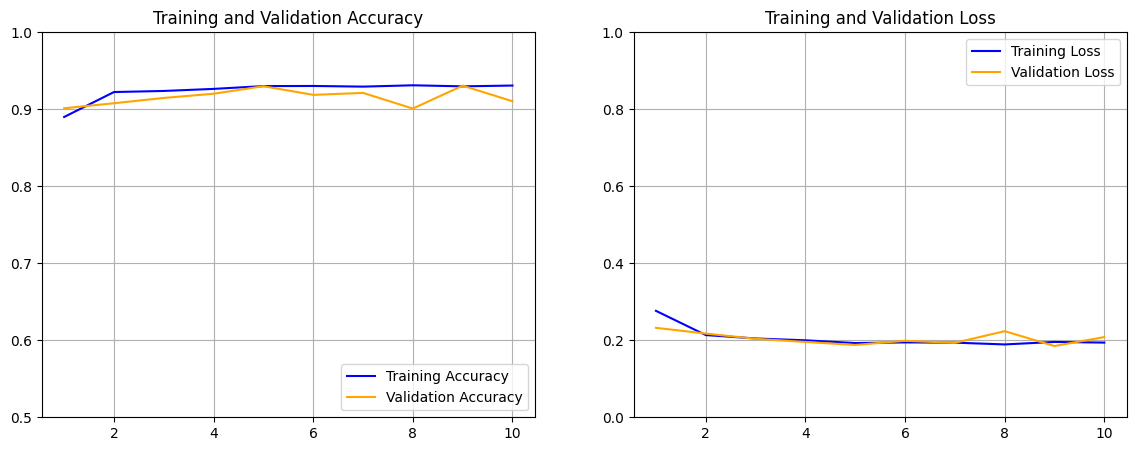

In [23]:
import matplotlib.pyplot as plt

# Extract data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Set up a 1x2 grid for plots
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.ylim(0.5, 1.0)
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.ylim(0.0, 1.0) 
plt.grid(True)

plt.show()

## step 14: testing the model

Loading image: C46P7ThinF_IMG_20151130_210309_cell_162.png
Running diagnostic scan...


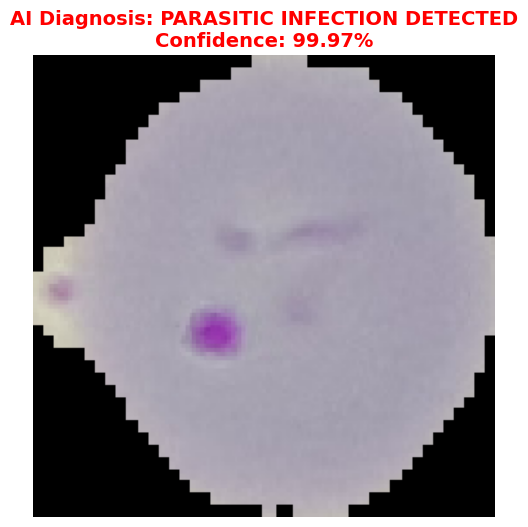

In [28]:
import random
from tensorflow.keras.preprocessing import image

# 1. Grab a random test image
test_folder = '/kaggle/working/malaria_split/test/Parasitized'
random_image_name = random.choice(os.listdir(test_folder))
img_path = os.path.join(test_folder, random_image_name)

# 2. Manual Preprocessing
print(f"Loading image: {random_image_name}")
img = image.load_img(img_path, target_size=(224, 224)) 
img_array = image.img_to_array(img)

# Normalize and Expand Dimensions
img_array_normalized = img_array / 255.0 
img_batch = np.expand_dims(img_array_normalized, axis=0) 

# 3. The Prediction
print("Running diagnostic scan...")
prediction_prob = model.predict(img_batch, verbose=0)[0][0]

# 4. The Diagnosis Logic (P=0, U=1)
if prediction_prob >= 0.5:
    # Closer to 1.0 -> Uninfected
    diagnosis = "HEALTHY CELL (UNINFECTED)"
    confidence = prediction_prob * 100
    text_color = 'green'
else:
    # Closer to 0.0 -> Parasitized
    diagnosis = "PARASITIC INFECTION DETECTED"
    confidence = (1 - prediction_prob) * 100
    text_color = 'red'

# 5. Visual Output
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"AI Diagnosis: {diagnosis}\nConfidence: {confidence:.2f}%", 
          fontsize=14, fontweight='bold', color=text_color)
plt.axis('off')
plt.show()

## Step 15: Saving the Model

In [29]:
model.save('malaria_cell_parasite_prediction_model.h5')